In [1]:
#00 中文處理
import matplotlib as mpl
import matplotlib.font_manager as fm

!wget "https://www.wfonts.com/download/data/2014/06/01/simhei/simhei.zip"
!unzip "simhei.zip"
!rm "simhei.zip"

fm.fontManager.addfont('SimHei.ttf')
mpl.rc('font', family='SimHei')
# 這一行能讓字體變得清晰
%config InlineBackend.figure_format = 'retina'
!pip install scikit-learn==1.1.3
import numpy as np
import pandas as pd
!pip install scikit-learn==1.1.3
from sklearn.linear_model import LinearRegression
from sklearn.datasets import load_boston

--2024-04-10 19:00:14--  https://www.wfonts.com/download/data/2014/06/01/simhei/simhei.zip
Resolving www.wfonts.com (www.wfonts.com)... 104.21.1.127, 172.67.129.58, 2606:4700:3031::ac43:813a, ...
Connecting to www.wfonts.com (www.wfonts.com)|104.21.1.127|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10546298 (10M) [application/octetstream]
Saving to: ‘simhei.zip’

simhei.zip          100%[===================>]  10.06M  --.-KB/s    in 0.1s    

2024-04-10 19:00:14 (74.4 MB/s) - ‘simhei.zip’ saved [10546298/10546298]

Archive:  simhei.zip
  inflating: chinese.simhei.ttf      
  inflating: SimHei.ttf              
  inflating: sharefonts.net.txt      
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.5/30.5 MB 9.9 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.2.2
    Uninstalling scikit-learn-1.2.2:
      Successfully uninstalled scikit-learn-1.2.2
ERROR: pip's dependency resolver does not currently take in

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
plt.rcParams['font.sans-serif'] = ['DFKai-sb']
plt.rcParams['axes.unicode_minus'] = False
import warnings
warnings.filterwarnings('ignore')
# 資料模組
from sklearn.datasets import load_boston
boston = load_boston()

In [3]:
df = pd.DataFrame(boston['data'], columns = boston['feature_names'])
df.head()
df['target'] = boston['target']
df.head()
X = df[['LSTAT']]
y = df['target']

In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                   test_size=0.33, random_state=42)

In [5]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

I.請將自變數 X 的欄位用'LSTAT'，再用線性回歸模型估算

a. 預測係數。

In [6]:
print('模型預測的係數',model.intercept_, model.coef_)

模型預測的係數 35.2251661672225 [-0.98053701]


b. 繪製預測結果和實際結果的散佈圖。

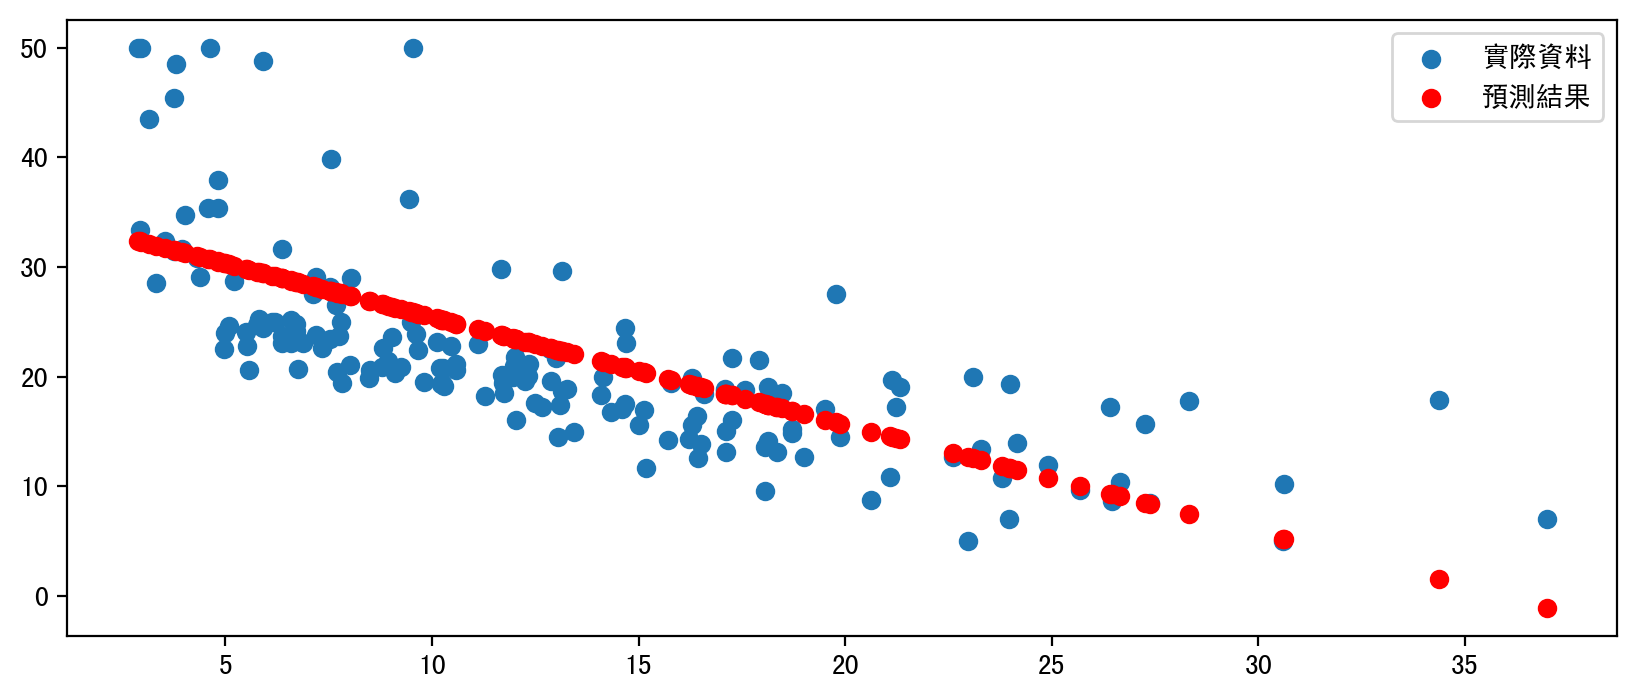

In [7]:
y_pred = model.predict(X_test)
fig, ax = plt.subplots(figsize=(10, 4))
plt.scatter(X_test, y_test, label='實際資料')
plt.scatter(X_test, y_pred, c='r', label='預測結果')
plt.legend()

c. 整體預測結果分析。

In [8]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
print('Mean Squred Error:',mean_squared_error(y_test, y_pred))
print('Mean Absolute Error:', mean_absolute_error(y_test, y_pred))
print('R2 Score:', r2_score(y_test, y_pred))

Mean Squred Error: 38.410075117662345
Mean Absolute Error: 4.744269760624963
R2 Score: 0.49245729145962347


In [9]:
X_train['LSTAT2'] = X_train['LSTAT']**2
X_test['LSTAT2'] = X_test['LSTAT']**2
X_train['LSTAT3'] = X_train['LSTAT']**3
X_test['LSTAT3'] = X_test['LSTAT']**3
X_train.head()

,LSTAT,LSTAT2,LSTAT3
478,18.03,325.0809,5861.208627
26,14.81,219.3361,3248.367641
7,19.15,366.7225,7022.735875
492,13.35,178.2225,2379.270375
108,12.27,150.5529,1847.284083


In [14]:
model_2 = LinearRegression()
model_2.fit(X_train, y_train)
y_pred = model_2.predict(X_test)

II.請將上例的 X 先三次方化，再進行一次預測。

a. 預測係數。

In [15]:
print('模型預測的係數',model_2.intercept_, model_2.coef_)

模型預測的係數 49.21529013606114 [-3.85946424e+00  1.44458484e-01 -1.89103933e-03]


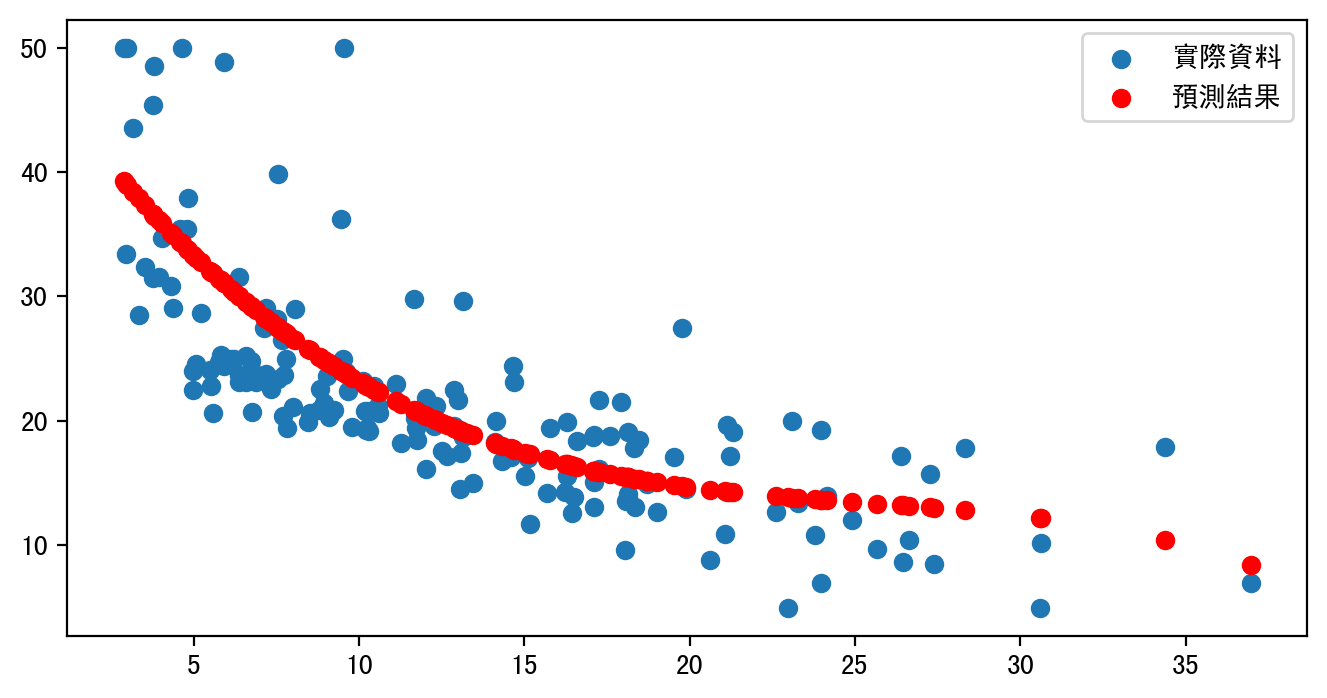

In [16]:
fig, ax = plt.subplots(figsize=(8, 4))
plt.scatter(X_test.iloc[:,0], y_test, label='實際資料')
plt.scatter(X_test.iloc[:,0], y_pred, c='r', label='預測結果')
plt.legend();

c. 整體預測結果分析。

In [17]:
print('Mean Squred Error:',mean_squared_error(y_test, y_pred))
print('Mean Absolute Error:', mean_absolute_error(y_test, y_pred))
print('R2 Score:', r2_score(y_test, y_pred))

Mean Squred Error: 30.66871726088512
Mean Absolute Error: 4.119200933191414
R2 Score: 0.5947499769691684
